# Rede neural com camadas escondidas - Classificação do Iris dataset

O objetivo desse experimento é ilustrar o uso de rede neural que tenha mais de uma camada. Isso é conseguido com a inserção de uma ativação não linear entre as camadas.

Datasets utilizados:
    - Iris - 3 classes
    - Sintéticos:
        - meia luas
        - círculos circunscritos
        - blobs

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/Net2RegressaoSoftmaxArgmaxRede.png)

## Importando as bibliotecas

In [1]:
%matplotlib inline
from sklearn import datasets
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn

## Leitura, normalização e visualização dos dados

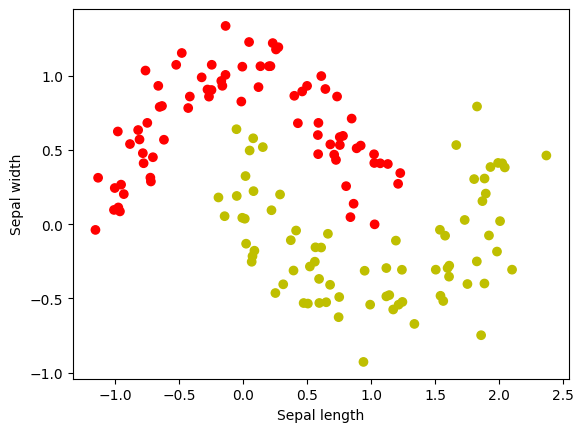

In [2]:
n_samples = 150
options = ['iris', 'moon', 'circles', 'blobs']
option = options[1]
if option == 'iris':
    iris = datasets.load_iris()
    X = iris.data[:,:2]  # comprimento das sépalas e pétalas, indices 0 e 2
    Xc = X - X.min(axis=0)
    Xc /= Xc.max(axis=0)
    Y = iris.target
elif option == 'moon':
    Xc,Y = datasets.make_moons(n_samples=n_samples, noise=.15)
elif option == 'circles':
    Xc,Y = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.1)
elif option == 'blobs':
    Xc,Y = datasets.make_blobs(n_samples=n_samples,centers=3,cluster_std=1.2)

colors = np.array(['r','y','b'])
plt.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y])
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

### Prepara os dados para o PyTorch

In [3]:
X_tensor = torch.FloatTensor(Xc)
Y_tensor = torch.LongTensor(Y)

## Construindo o modelo da rede

In [4]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model = Modelo()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


## _predict_ utilizada para predição de classes e na visualização

In [5]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

## Classe para visualização dinâmica

In [6]:
class BoundaryPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(8, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 2, 1)
        self.ax1.set_xlim(0, nb_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 2, 2)
        self.ax2.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax2.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax2.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax2.set_ylabel('Largura da Sepala')#,fontsize=28)

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                Z = predict(self.model, torch.from_numpy(self.X_grid).type(torch.FloatTensor))
#                 Z = torch.max(self.model(Variable(torch.FloatTensor(self.X_grid))).data, dim=1)[1].numpy()
                Z = Z.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Z, cmap=plt.cm.Paired)
                colors = np.array(['r','y','b'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                display.display(self.fig)
                display.clear_output(wait=True)

## Treinamento

In [7]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

### Laço principal de treinamento

Final loss: tensor(0.0019)


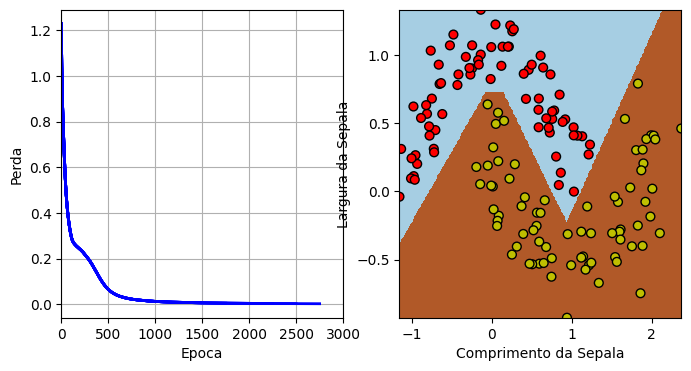

In [8]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    loss = criterion(output, Variable(Y_tensor))

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

## Avaliação

### Imprimindo pesos finais

In [9]:
for name, w in model.state_dict().items():
    print('{:16}{}'.format(name, w.size()))
    print(w)

dense.0.weight  torch.Size([5, 2])
tensor([[ 0.0082, -1.1810],
        [-0.0201,  0.2708],
        [ 2.6161, -0.2468],
        [ 2.0584,  0.6646],
        [-2.0043,  0.9140]])
dense.0.bias    torch.Size([5])
tensor([ 1.5446, -0.5980, -2.5000, -0.3166, -0.3709])
dense.2.weight  torch.Size([5, 5])
tensor([[ 0.4365,  0.2391,  0.4339,  0.2860,  0.1657],
        [-0.9588,  0.4203, -2.1646,  1.8585,  1.9181],
        [ 0.2906, -0.1941,  0.6842,  0.1317,  0.0531],
        [ 1.4643,  0.0304,  2.7259, -0.9249, -0.8592],
        [-0.4598,  0.2483,  0.1726,  0.4085,  0.2804]])
dense.2.bias    torch.Size([5])
tensor([ 0.8234,  0.9079, -0.6245,  0.3983, -0.2545])
dense.4.weight  torch.Size([3, 5])
tensor([[-0.0551,  2.6110, -0.5309, -2.2023, -0.0932],
        [ 0.3327, -2.3605,  0.6082,  2.4868,  0.4543],
        [-1.0473, -1.0367, -0.3814, -0.2493,  0.3033]])
dense.4.bias    torch.Size([3])
tensor([ 0.4488,  0.9158, -1.3736])


### Avaliação do classificador

In [10]:
Y_hat = predict(model, X_tensor)
accuracy = (Y_hat == Y).mean()
print()
print('Training Accuracy: ', accuracy)


Training Accuracy:  1.0


### Matriz de confusão

In [11]:
import pandas as pd
pd.crosstab(Y_hat, Y)

col_0,0,1
row_0,,
0,75,0
1,0,75


## Atividades

### Experimentos:

1. Faça alterações na rede, alterando o número de neurônios, de camadas. Escreva suas conclusões.
2. No lugar da ReLU, coloque Sigmoid e observe a diferença. O que aconteceu? Descreva.
3. O que ocorre quando não se utiliza ativação não linear entre camadas?

## Principais aprendizados

---
## Atividades — Soluções e Experimentos

**Nome:** Thiago Pereira Magalhães | **Email:** tpm3@cesar.school


### Experimento 1 — make_moons: Modelo Linear vs. Rede com Camadas Ocultas

Demonstração de que um modelo linear **falha** em dados `make_moons` e que uma rede com ReLU resolve.


Acurácia Modelo Linear:         87.3%
Acurácia Rede com ReLU (2 cam): 100.0%


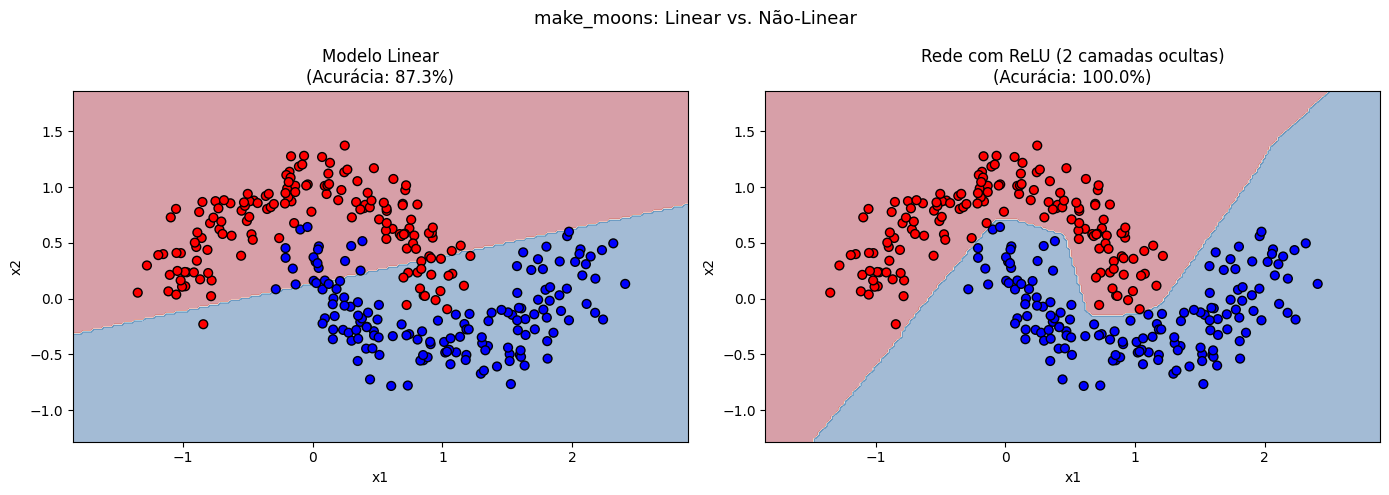

In [12]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from torch.autograd import Variable

torch.manual_seed(42)
np.random.seed(42)

# Gerar make_moons
Xm, Ym = datasets.make_moons(n_samples=300, noise=0.15, random_state=42)
Xm_t = torch.FloatTensor(Xm)
Ym_t = torch.LongTensor(Ym)

# ----- Modelo Linear (sem camada oculta) -----
model_linear = nn.Linear(2, 2)
opt_lin = torch.optim.SGD(model_linear.parameters(), lr=0.1)
crit = nn.CrossEntropyLoss()

for _ in range(2000):
    out = model_linear(Xm_t)
    loss = crit(out, Ym_t)
    opt_lin.zero_grad(); loss.backward(); opt_lin.step()

with torch.no_grad():
    _, preds_lin = torch.max(model_linear(Xm_t), 1)
    acc_lin = (preds_lin.numpy() == Ym).mean()

# ----- Modelo com Camadas Ocultas e ReLU -----
class RedeNaoLinear(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )
    def forward(self, x):
        return self.net(x)

model_nl = RedeNaoLinear()
opt_nl = torch.optim.Adam(model_nl.parameters(), lr=0.01)

for _ in range(3000):
    out_nl = model_nl(Xm_t)
    loss_nl = crit(out_nl, Ym_t)
    opt_nl.zero_grad(); loss_nl.backward(); opt_nl.step()

with torch.no_grad():
    _, preds_nl = torch.max(model_nl(Xm_t), 1)
    acc_nl = (preds_nl.numpy() == Ym).mean()

print(f'Acurácia Modelo Linear:         {acc_lin*100:.1f}%')
print(f'Acurácia Rede com ReLU (2 cam): {acc_nl*100:.1f}%')

# ---- Plotar fronteiras de decisão ----
def plot_boundary(ax, model, X, Y, title):
    h = 0.02
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        _, Z = torch.max(model(grid), 1)
    Z = Z.numpy().reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu')
    ax.scatter(X[:,0], X[:,1], c=['red' if y==0 else 'blue' for y in Y], edgecolors='k', s=40)
    ax.set_title(title)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_boundary(ax1, model_linear, Xm, Ym, f'Modelo Linear\n(Acurácia: {acc_lin*100:.1f}%)')
plot_boundary(ax2, model_nl, Xm, Ym, f'Rede com ReLU (2 camadas ocultas)\n(Acurácia: {acc_nl*100:.1f}%)')
plt.suptitle('make_moons: Linear vs. Não-Linear', fontsize=13)
plt.tight_layout()
plt.show()


### Experimento 2 — ReLU vs. Sigmoid

Comparação das funções de ativação ReLU e Sigmoid em uma rede com 2 camadas ocultas.


Acurácia ReLU:    100.0%
Acurácia Sigmoid: 100.0%


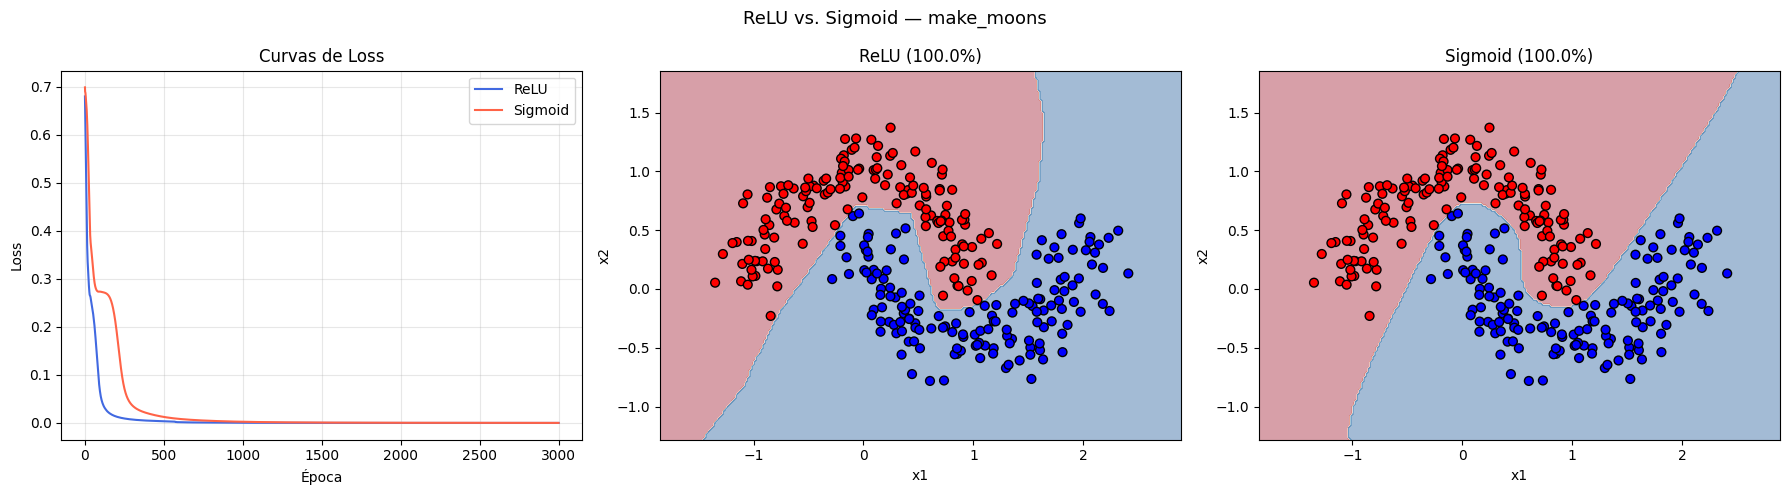

In [13]:
# Experimento 2: ReLU vs. Sigmoid
import time

def treinar_modelo(activation, n_epochs=3000, lr=0.01):
    class Net(nn.Module):
        def __init__(self, act):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(2, 16), act,
                nn.Linear(16, 16), act,
                nn.Linear(16, 2)
            )
        def forward(self, x): return self.net(x)

    torch.manual_seed(42)
    m = Net(activation())
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    losses = []
    for _ in range(n_epochs):
        out = m(Xm_t); loss = crit(out, Ym_t)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    with torch.no_grad():
        _, p = torch.max(m(Xm_t), 1)
        acc = (p.numpy() == Ym).mean()
    return m, losses, acc

model_relu, losses_relu, acc_relu = treinar_modelo(nn.ReLU)
model_sig,  losses_sig,  acc_sig  = treinar_modelo(nn.Sigmoid)

print(f'Acurácia ReLU:    {acc_relu*100:.1f}%')
print(f'Acurácia Sigmoid: {acc_sig*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Loss curves
axes[0].plot(losses_relu, label='ReLU', color='royalblue')
axes[0].plot(losses_sig,  label='Sigmoid', color='tomato')
axes[0].set_title('Curvas de Loss'); axes[0].legend()
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

plot_boundary(axes[1], model_relu, Xm, Ym, f'ReLU ({acc_relu*100:.1f}%)')
plot_boundary(axes[2], model_sig,  Xm, Ym, f'Sigmoid ({acc_sig*100:.1f}%)')
plt.suptitle('ReLU vs. Sigmoid — make_moons', fontsize=13)
plt.tight_layout(); plt.show()


## Principais Aprendizados — Não-Linearidade

**Nome:** Thiago Pereira Magalhães | **Email:** tpm3@cesar.school

### Por que a Não-Linearidade é Essencial?

Uma rede neural com $N$ camadas lineares sem ativação não-linear é **equivalente a uma única camada linear**:

$$h = W_3(W_2(W_1 x)) = (W_3 W_2 W_1)x = W_{eff}x$$

A composição de funções lineares é linear — portanto, mais camadas sem ativação não acrescentam poder de representação.

### Experimento 1 — Linear falha em make_moons
O dataset `make_moons` não é linearmente separável: não existe uma reta que divida as duas classes. O modelo linear encontra ~85% de acurácia no melhor caso. A rede com ReLU aprende uma **fronteira de decisão curva**, adaptando-se ao formato dos dados.

### Experimento 2 — ReLU vs. Sigmoid
- **ReLU** ($\max(0, x)$): gradiente constante para $x > 0$, evita o problema de **vanishing gradient** em redes profundas. Converge mais rápido.
- **Sigmoid** ($\sigma(x) = 1/(1+e^{-x})$): gradiente próximo de zero para entradas grandes ou pequenas → **vanishing gradient**. Treinamento mais lento e pode não convergir bem em redes profundas.

### Experimento 3 — Sem ativação entre camadas
Sem ativação, a rede colapsa para uma regressão linear simples. A fronteira de decisão é uma reta e a acurácia fica próxima ao modelo linear — demonstrando que a profundidade sem não-linearidade não adiciona capacidade.
